# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные.

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


Подключим библиотеки которые потребуются для проведения исследований

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from phik import phik_matrix
import seaborn as sns

from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

Настрим строку подключения к базе данных

In [19]:
load_dotenv(dotenv_path=".env")

db_config = {
    "user": os.getenv("DB_USER"),
    "pwd": os.getenv("DB_PWD"),
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "db": os.getenv("DB_NAME"),
}

connection_string = "postgresql://{}:{}@{}:{}/{}".format(
    db_config["user"],
    db_config["pwd"],
    db_config["host"],
    db_config["port"],
    db_config["db"],
)

Запрос для получения данных

In [20]:
query = """
SELECT 
    -- уникальный идентификатор пользователя, совершившего заказ
    user_id
    -- тип устройства, с которого был оформлен заказ (например, mobile — мобильные устройства, desktop — стационарные)
    , device_type_canonical
    -- уникальный идентификатор заказа
    , order_id
    -- дата создания заказа (используйте данные created_dt_msk )
    , created_dt_msk AS order_dt
    -- дата и время создания заказа (используйте данные created_ts_msk )
    , created_ts_msk AS order_ts
    -- валюта оплаты
    , currency_code
    -- выручка от заказа
    , revenue
    -- количество купленных билетов
    , tickets_count
    -- количество дней между этой покупкой и предыдущей. Если пользователь совершал только одну покупку, то в столбце должно быть пропущенное значение
    , created_dt_msk::date - (LAG(created_dt_msk::date) OVER(PARTITION BY user_id ORDER BY created_dt_msk)) AS days_since_prev
    -- уникальный идентификатор мероприятия
    , event_id
    -- название мероприятия (используйте данные event_name_code)
    , event_name_code AS event_name
    -- название билетного оператора
    , service_name
    -- основной тип мероприятия (театральная постановка, концерт и так далее)
    , event_type_main
    -- название региона, в котором прошло мероприятие
    , region_name
    -- название города, в котором прошло мероприятие
    , city_name
  FROM afisha.purchases
  INNER JOIN afisha.events USING (event_id)
  JOIN afisha.city USING (city_id)
  JOIN afisha.regions USING (region_id)
  WHERE 1=1
    -- При выгрузке используйте только заказы, совершённые с мобильных и десктопных устройств. С других типов устройств заказов было совершено слишком мало, поэтому можно их не учитывать.
    AND device_type_canonical IN ('mobile', 'desktop')
    -- Исключите из данных заказы билетов на фильмы, так как по ним недостаточно данных.
    AND event_type_main != 'фильм'
  ORDER BY user_id
"""

Получаем данные из базы в датафрейм

In [21]:
engine = create_engine(connection_string)
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  service_name           290611 non-null  str           
 12  event_type_main        290611 non-null  str           


In [23]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


Всего в датафрейме 290611 записей и 15 колонок.

Данные соотвествуют описанию.

Можно провести следующие оптимизации типов данных:
- Тип данных для колонок device_type_canonical, currency_code, event_type_main можно привести к категориальному.
- Тип данных для колонки tickets_count можно оптимизировать и привести к более компактному типа (например int8).
- Тип данных для колонки days_since_prev можно привести к целочисленному более компактному ввиду (но в данных есть пропуски - рассмотрим это далее).

В данных присутствуют пропуски в колонке days_since_prev. Известно что эти пропуски соответсвуют пользователям которые пришли первый раз и их замена может отразится на исследованиях.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


Загрузим данные о курсе казахстанского тенге в датасет

In [24]:
final_tickets_tenge_df = pd.read_csv(
    "https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv"
)

Изучим данные в final_tickets_tenge_df

In [25]:
final_tickets_tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [26]:
final_tickets_tenge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


Датасет final_tickets_tenge_df содержит 357 записей и 4 колонок. Курс казахстанского тенге представлени в колонке curs и отображает курс на конкретную дату (колонка data) для 100 тенге. В данных нет пропусков. Данные в столбце data являются датами, преобразуем их в подходящий тип данных и сохраним в колонке date.

In [27]:
final_tickets_tenge_df["date"] = pd.to_datetime(final_tickets_tenge_df["data"])

In [28]:
final_tickets_tenge_df.head()

,data,nominal,curs,cdx,date
0,2024-01-10,100,19.9391,kzt,2024-01-10
1,2024-01-11,100,19.7255,kzt,2024-01-11
2,2024-01-12,100,19.5839,kzt,2024-01-12
3,2024-01-13,100,19.4501,kzt,2024-01-13
4,2024-01-14,100,19.4501,kzt,2024-01-14


Создадим функцию fill_revenue_rub для преобразования revenue из тенге в рубли (для рублей будем использовать данные без преобразования), используя курс на соответствующую дату из final_tickets_tenge_df, и сохраним данные в колонке revenue_rub

In [29]:
def fill_revenue_rub(row):
    if row["currency_code"] == "kzt":
        tenge_df_row = final_tickets_tenge_df[
            final_tickets_tenge_df["date"] == row["order_dt"]
        ]
        curs = tenge_df_row["curs"].values[0] / tenge_df_row["nominal"].values[0]
        return row["revenue"] * curs
    else:
        return row["revenue"]


df["revenue_rub"] = df.apply(fill_revenue_rub, axis=1)

In [30]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк,1390.41


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  service_name           290611 non-null  str           
 12  event_type_main        290611 non-null  str           


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Проверим наличие пропусков

In [32]:
pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_share": df.isna().mean() * 100,
    }
).sort_values("missing_share", ascending=False)

,missing_count,missing_share
days_since_prev,21933,7.547202
user_id,0,0.000000
order_id,0,0.000000
device_type_canonical,0,0.000000
order_ts,0,0.000000
currency_code,0,0.000000
revenue,0,0.000000
order_dt,0,0.000000
tickets_count,0,0.000000
event_id,0,0.000000


В данных присутствуют пропуски в колонке days_since_prev. Известно что эти пропуски соответсвуют пользователям которые пришли первый раз. Если мы заменим эти пропуски на значения это повлияет на рассчеты исследований, удалять их также нельзя т.к. эти записи важны для исследования.

Тип данных для колонок device_type_canonical, currency_code, event_type_main можно привести к категориальному.

In [33]:
df["device_type_canonical"] = df["device_type_canonical"].astype("category")
df["currency_code"] = df["currency_code"].astype("category")
df["event_type_main"] = df["event_type_main"].astype("category")

Тип данных для колонки tickets_count можно попробовать оптимизировать и привести к более компактному типа (например int8).

In [34]:
df["tickets_count"] = pd.to_numeric(df["tickets_count"], downcast="integer")

Также попробуем оптимизировать тип данных для колонки days_since_prev и привести к более компактному типа (например float32).

In [35]:
df["days_since_prev"] = pd.to_numeric(df["days_since_prev"], downcast="float")

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  service_name           290611 non-null  str           
 12  event_type_main        290611 non-null  category      


Изучим номинальные значения device_type_canonical, currency_code, event_type_main

In [37]:
df["device_type_canonical"].value_counts()

device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

In [38]:
df["currency_code"].value_counts()

currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

In [39]:
df["event_type_main"].value_counts()

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

Данные в колонках device_type_canonical, currency_code, event_type_main нормализованы и отвечают описанию. В данных нет явных ошибок.

Изучим данные в столбце revenue_rub

In [40]:
df["revenue_rub"].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
99%        2628.421739
max       81174.540000
Name: revenue_rub, dtype: float64

In [41]:
df_with_negative_revenue = df[df["revenue_rub"] < 0]

In [42]:
df_with_negative_revenue["revenue_rub"].describe()

count    381.000000
mean      -2.492362
std        5.065072
min      -90.760000
25%       -3.450000
50%       -1.580000
75%       -0.650000
max       -0.010000
Name: revenue_rub, dtype: float64

In [43]:
len(df_with_negative_revenue) / len(df)

0.0013110308969722412

В данных по выручке присутствуют отрицательные значение, которые могут исказить результаты иследований. Можно предположить, что эти данные отражают возвраты или специальные транзакции (например для авторизации пользователя).
Т.к. таких данные менее 1% - удалим их из датасета.

In [44]:
df = df.loc[df["revenue_rub"] >= 0]

In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 290230 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290230 non-null  str           
 1   device_type_canonical  290230 non-null  category      
 2   order_id               290230 non-null  int64         
 3   order_dt               290230 non-null  datetime64[us]
 4   order_ts               290230 non-null  datetime64[us]
 5   currency_code          290230 non-null  category      
 6   revenue                290230 non-null  float64       
 7   tickets_count          290230 non-null  int8          
 8   days_since_prev        268329 non-null  float32       
 9   event_id               290230 non-null  int64         
 10  event_name             290230 non-null  str           
 11  service_name           290230 non-null  str           
 12  event_type_main        290230 non-null  category      
 13  

Изучим распределение данные выручки

<Axes: title={'center': 'Распределение суммы выручки'}, ylabel='Frequency'>

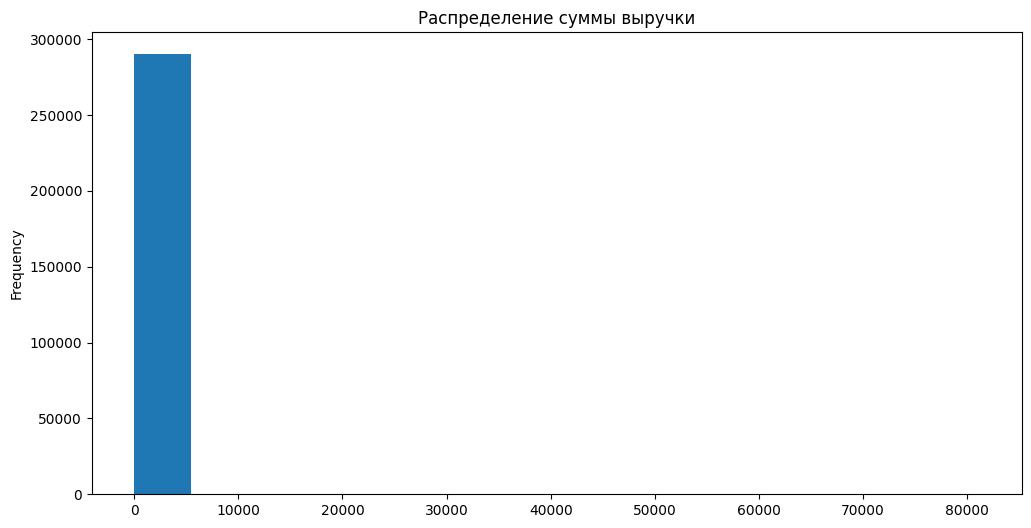

In [46]:
df["revenue_rub"].plot.hist(
    title="Распределение суммы выручки",
    figsize=(12, 6),
    bins=15,
)

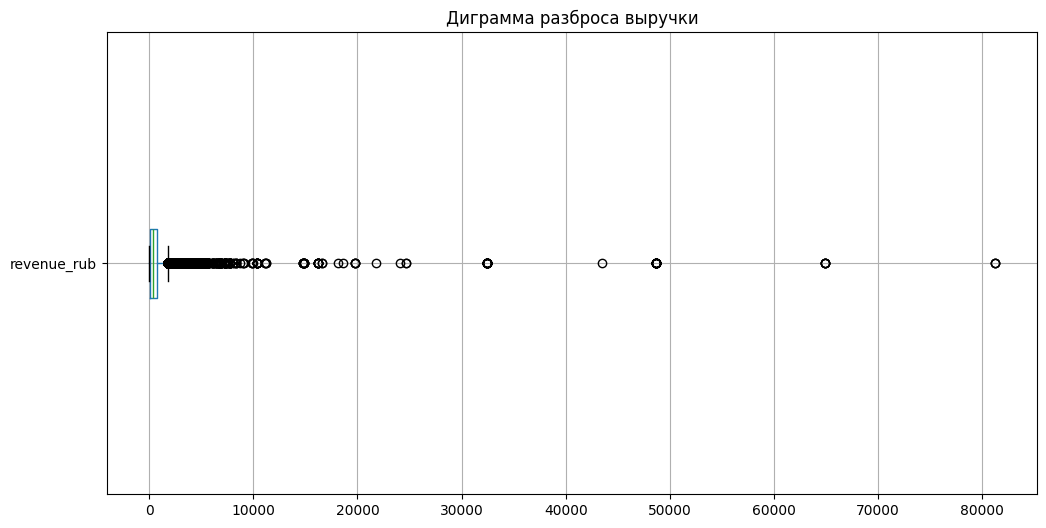

In [47]:
df.boxplot(column="revenue_rub", vert=False, figsize=(12, 6))
plt.title("Диграмма разброса выручки")
plt.show()

В данных выручки наблюдаются заметные выбросы, отфильтруем данные по 99 перцентилю.

In [48]:
revenue_99_percentile = df["revenue_rub"].quantile(q=0.99)
df = df.loc[df["revenue_rub"] <= revenue_99_percentile]
df.info()

<class 'pandas.DataFrame'>
Index: 287405 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287405 non-null  str           
 1   device_type_canonical  287405 non-null  category      
 2   order_id               287405 non-null  int64         
 3   order_dt               287405 non-null  datetime64[us]
 4   order_ts               287405 non-null  datetime64[us]
 5   currency_code          287405 non-null  category      
 6   revenue                287405 non-null  float64       
 7   tickets_count          287405 non-null  int8          
 8   days_since_prev        265711 non-null  float32       
 9   event_id               287405 non-null  int64         
 10  event_name             287405 non-null  str           
 11  service_name           287405 non-null  str           
 12  event_type_main        287405 non-null  category      
 13  

<Axes: title={'center': 'Распределение суммы выручки'}, ylabel='Frequency'>

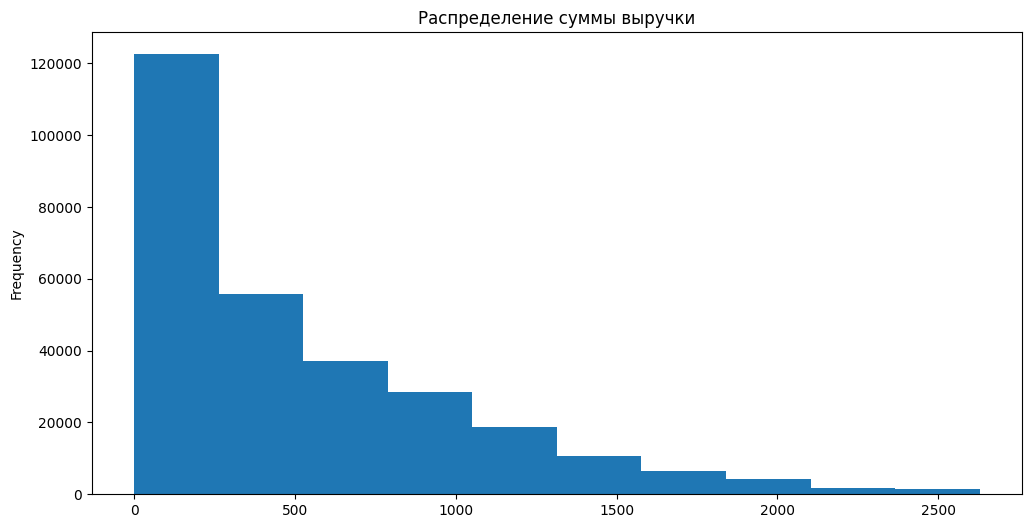

In [49]:
df["revenue_rub"].plot.hist(title="Распределение суммы выручки", figsize=(12, 6))

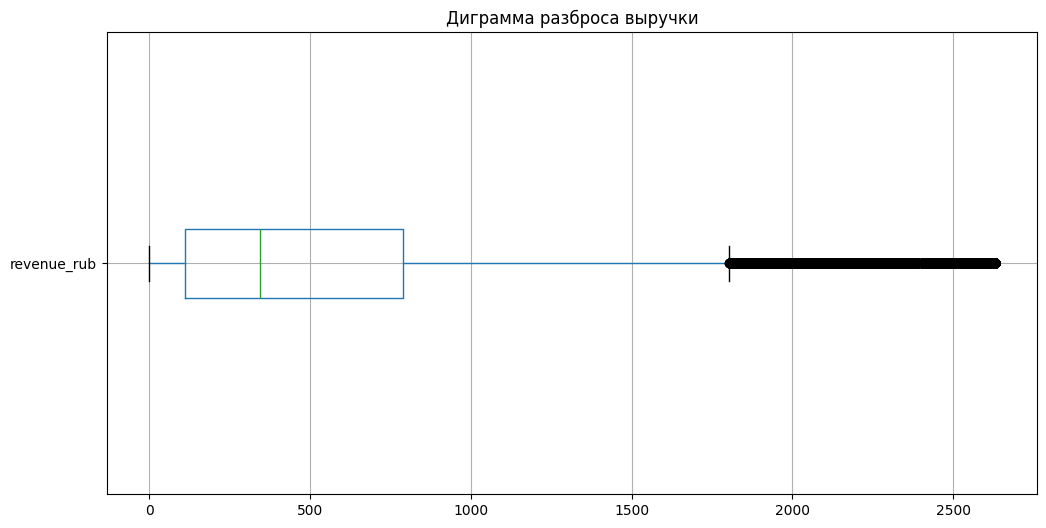

In [50]:
df.boxplot(column="revenue_rub", vert=False, figsize=(12, 6))
plt.title("Диграмма разброса выручки")
plt.show()

В результате обработки данных столбца revenue_rub были удалены записи с отрицательными значениями (381 запись), а также отфильтрованны выбросы по 99 перцентилю (2444 записи) теперь в датафрейму 287786 записей.

Изучим столбец с количество проданных билетов tickets_count

In [51]:
df["tickets_count"].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

count    287405.000000
mean          2.741323
std           1.163087
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

<Axes: title={'center': 'Распределение количества билетов'}, ylabel='Frequency'>

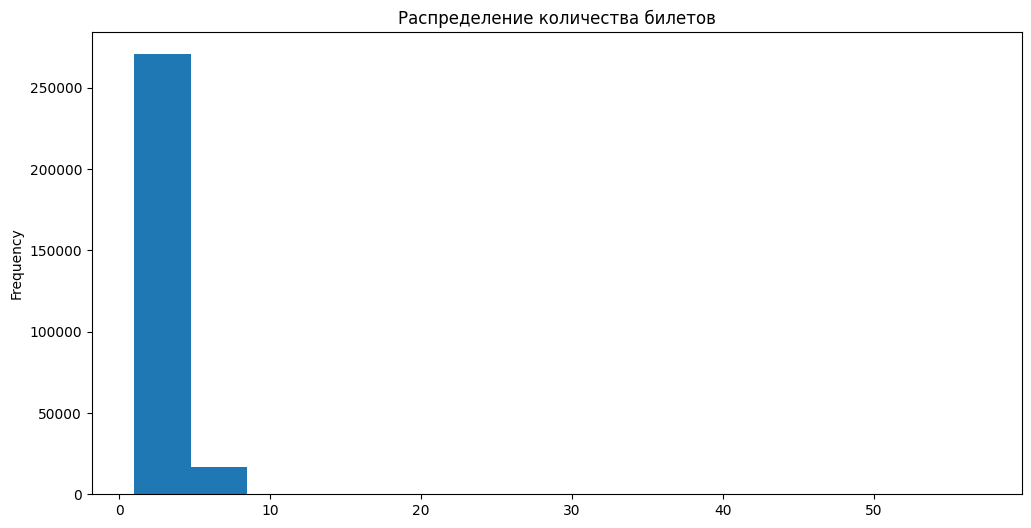

In [52]:
df["tickets_count"].plot.hist(
    title="Распределение количества билетов",
    figsize=(12, 6),
    bins=15,
)

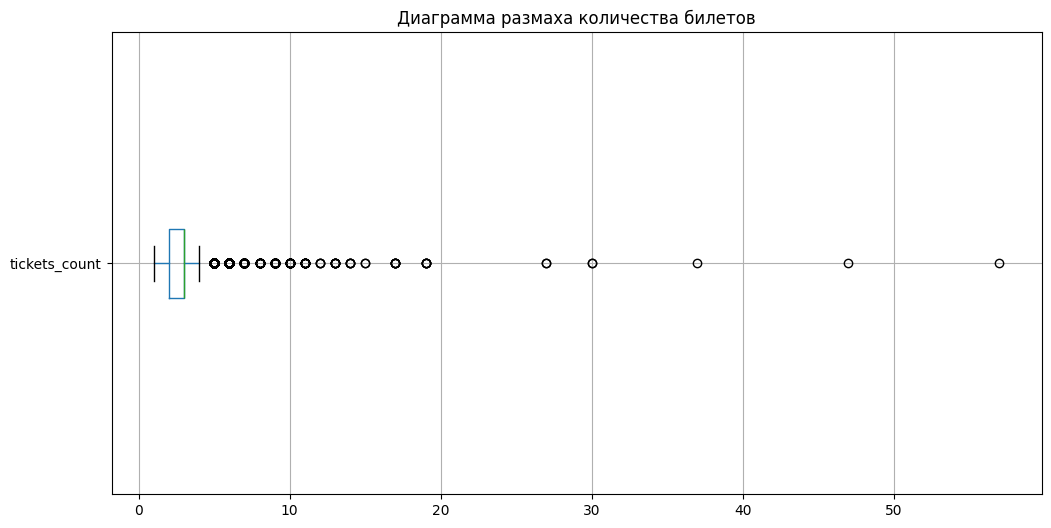

In [53]:
df.boxplot(column="tickets_count", vert=False, figsize=(12, 6))
plt.title("Диаграмма размаха количества билетов")
plt.show()

В данных по проданным билетам так же присутсвуют выбросы, скорей всего это какие то единичные покупки корпоративного характера. Отфильтруем данные по 99 перцентилю.

In [54]:
tickets_99_percentile = df["tickets_count"].quantile(q=0.99)
df = df.loc[df["tickets_count"] <= tickets_99_percentile]
df.info()

<class 'pandas.DataFrame'>
Index: 287225 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287225 non-null  str           
 1   device_type_canonical  287225 non-null  category      
 2   order_id               287225 non-null  int64         
 3   order_dt               287225 non-null  datetime64[us]
 4   order_ts               287225 non-null  datetime64[us]
 5   currency_code          287225 non-null  category      
 6   revenue                287225 non-null  float64       
 7   tickets_count          287225 non-null  int8          
 8   days_since_prev        265542 non-null  float32       
 9   event_id               287225 non-null  int64         
 10  event_name             287225 non-null  str           
 11  service_name           287225 non-null  str           
 12  event_type_main        287225 non-null  category      
 13  

<Axes: title={'center': 'Распределение количества билетов'}, ylabel='Frequency'>

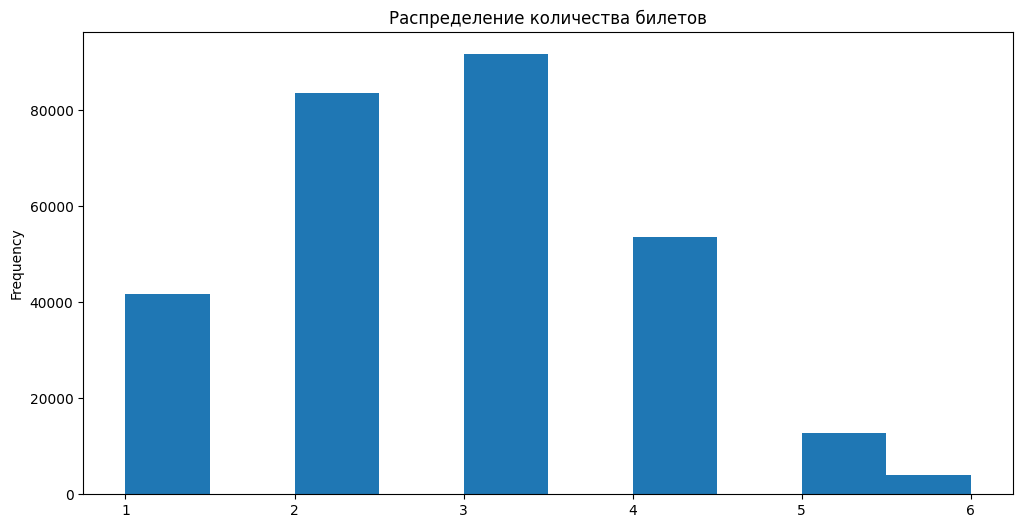

In [55]:
df["tickets_count"].plot.hist(
    title="Распределение количества билетов",
    figsize=(12, 6),
)

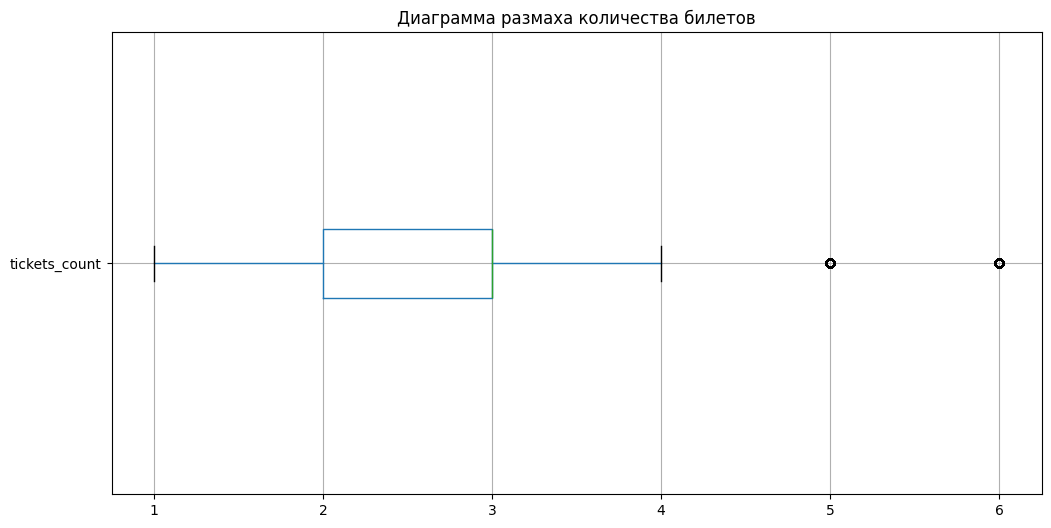

In [56]:
df.boxplot(column="tickets_count", vert=False, figsize=(12, 6))
plt.title("Диаграмма размаха количества билетов")
plt.show()

In [57]:
df.info()

<class 'pandas.DataFrame'>
Index: 287225 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287225 non-null  str           
 1   device_type_canonical  287225 non-null  category      
 2   order_id               287225 non-null  int64         
 3   order_dt               287225 non-null  datetime64[us]
 4   order_ts               287225 non-null  datetime64[us]
 5   currency_code          287225 non-null  category      
 6   revenue                287225 non-null  float64       
 7   tickets_count          287225 non-null  int8          
 8   days_since_prev        265542 non-null  float32       
 9   event_id               287225 non-null  int64         
 10  event_name             287225 non-null  str           
 11  service_name           287225 non-null  str           
 12  event_type_main        287225 non-null  category      
 13  

В столбце tickets_count были обнаружены выбросы и данные были отфильтрованы по 99 перцентилю. 561 записей было удаленно, теперь в датафрейму 287225 записей.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


Построим профиль пользователя со следующими колонками:
- first_order_ts - дата первого заказа;
- last_order_ts - дата последнего заказа;
- first_device_type_canonical - устройство, с которого был сделан первый заказ;
- first_order_region - регион, в котором был сделан первый заказ;
- first_order_service - билетного партнёра, к которому обращались при первом заказе;
- first_order_event_type - жанр первого посещённого мероприятия (поле event_type_main);
- total_orders - общее количество заказов;
- avg_revenue_rub - средняя выручка с одного заказа в рублях;
- avg_tickets_count - среднее количество билетов в заказе;
- avg_days_since_prev - среднее время между заказами.

In [58]:
df_user_profile = (
    df.sort_values(by="order_ts")
    .groupby("user_id")
    .agg(
        first_order_ts=("order_ts", "first"),
        last_order_ts=("order_ts", "last"),
        first_device_type_canonical=("device_type_canonical", "first"),
        first_order_region=("region_name", "first"),
        first_order_service=("service_name", "first"),
        first_order_event_type=("event_type_main", "first"),
        total_orders=("user_id", "count"),
        avg_revenue_rub=("revenue_rub", "mean"),
        avg_tickets_count=("tickets_count", "mean"),
        avg_days_since_prev=("days_since_prev", "mean"),
    )
)
df_user_profile.head()

,first_order_ts,last_order_ts,first_device_type_canonical,first_order_region,first_order_service,first_order_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev
user_id,,,,,,,,,,
0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN
0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0
000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0
00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN
000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0


Добавим две колонки типа bool:
- is_two — совершил ли пользователь 2 и более заказа;
- is_five — совершил ли пользователь 5 и более заказов.

In [59]:
df_user_profile["is_two"] = df_user_profile["total_orders"] >= 2
df_user_profile["is_five"] = df_user_profile["total_orders"] >= 5
df_user_profile.head()

,first_order_ts,last_order_ts,first_device_type_canonical,first_order_region,first_order_service,first_order_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [60]:
len(df_user_profile)

21831

Общее число пользователей в выборке 21831

In [61]:
df_user_profile["avg_revenue_rub"].mean()

np.float64(544.7958478435195)

Средняя выручка с одного заказа ~544.8

In [62]:
df_user_profile["is_two"].mean()

np.float64(0.616966698731162)

Доля пользователей, совершивших 2 и более заказа ~62%

In [63]:
df_user_profile["is_five"].mean()

np.float64(0.2899546516421602)

Доля пользователей, совершивших 5 и более заказов ~29%

Исследуем статистические показатели по общему числу заказов, по среднему числу билетов в заказе, по среднему количеству дней между покупками

In [64]:
df_user_profile["total_orders"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

count    21831.000000
mean        13.156750
std        121.484319
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
95%         31.000000
99%        151.700000
max      10155.000000
Name: total_orders, dtype: float64

In [65]:
df_user_profile["avg_tickets_count"].describe()

count    21831.000000
mean         2.740095
std          0.902688
min          1.000000
25%          2.000000
50%          2.750000
75%          3.071429
max          6.000000
Name: avg_tickets_count, dtype: float64

In [66]:
df_user_profile["avg_days_since_prev"].describe()

count    13506.000000
mean        15.834014
std         22.288393
min          0.000000
25%          1.000000
50%          8.000000
75%         20.333334
max        148.000000
Name: avg_days_since_prev, dtype: float64

В данных по количеству заказов есть выбросу, посмотрим на них на графиках

<Axes: title={'center': 'Распределение общего количества заказова'}, ylabel='Frequency'>

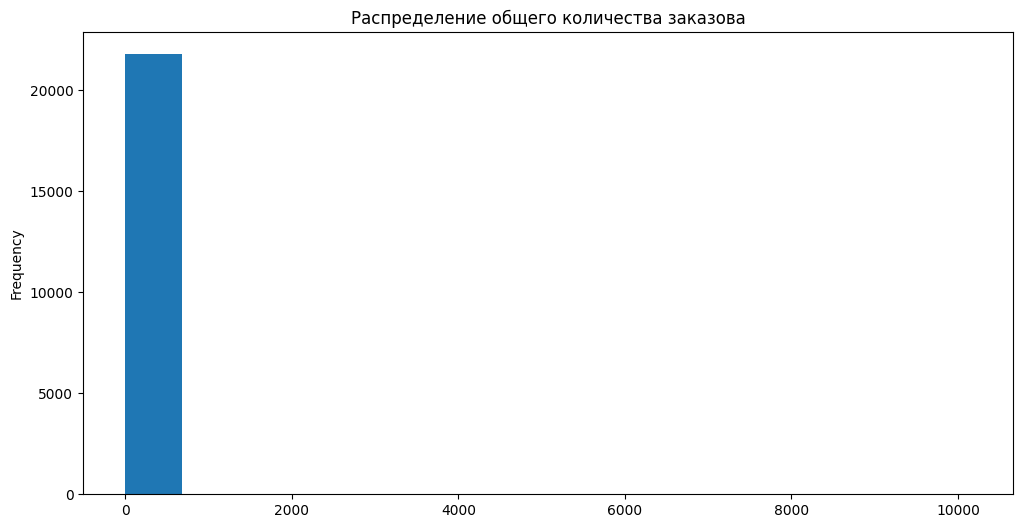

In [67]:
df_user_profile["total_orders"].plot.hist(
    title="Распределение общего количества заказова",
    figsize=(12, 6),
    bins=15,
)

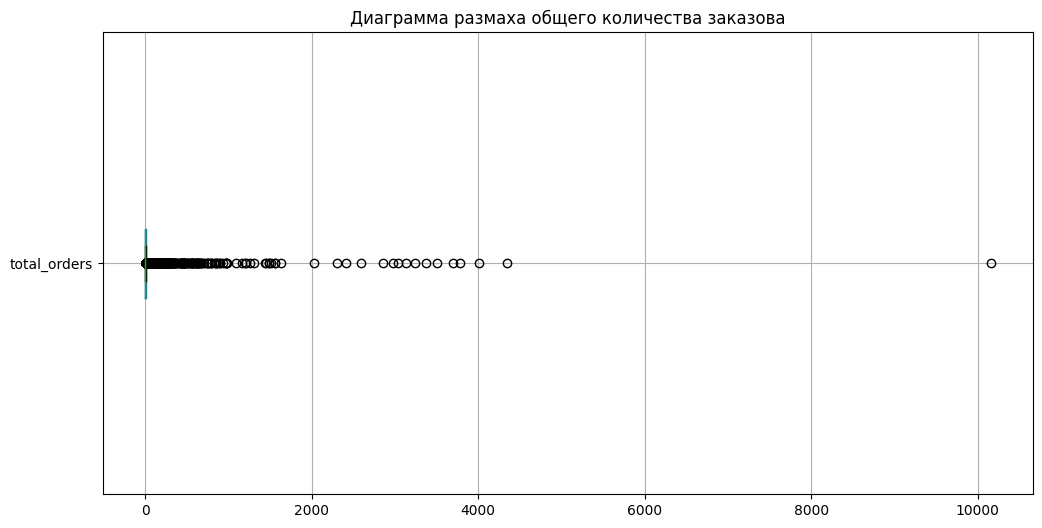

In [68]:
df_user_profile.boxplot(
    column="total_orders",
    vert=False,
    figsize=(12, 6),
)
plt.title("Диаграмма размаха общего количества заказова")
plt.show()

Отфильтруем данные по количеству заказов на уровне 95 перцентиля

In [69]:
total_orders_percentile_95 = df_user_profile["total_orders"].quantile(q=0.95)
df_user_profile = df_user_profile[
    df_user_profile["total_orders"] <= total_orders_percentile_95
]
df_user_profile.info()

<class 'pandas.DataFrame'>
Index: 20741 entries, 0002849b70a3ce2 to ffff00725179321
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   first_order_ts               20741 non-null  datetime64[us]
 1   last_order_ts                20741 non-null  datetime64[us]
 2   first_device_type_canonical  20741 non-null  category      
 3   first_order_region           20741 non-null  str           
 4   first_order_service          20741 non-null  str           
 5   first_order_event_type       20741 non-null  category      
 6   total_orders                 20741 non-null  int64         
 7   avg_revenue_rub              20741 non-null  float64       
 8   avg_tickets_count            20741 non-null  float64       
 9   avg_days_since_prev          12416 non-null  float32       
 10  is_two                       20741 non-null  bool          
 11  is_five                      2074

<Axes: title={'center': 'Распределение общего количества заказова'}, ylabel='Frequency'>

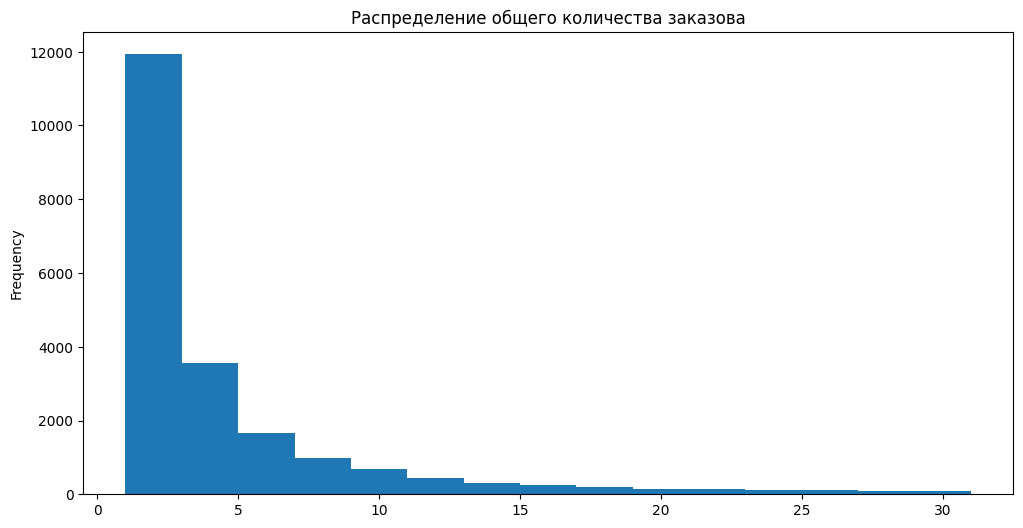

In [70]:
df_user_profile["total_orders"].plot.hist(
    title="Распределение общего количества заказова",
    figsize=(12, 6),
    bins=15,
)

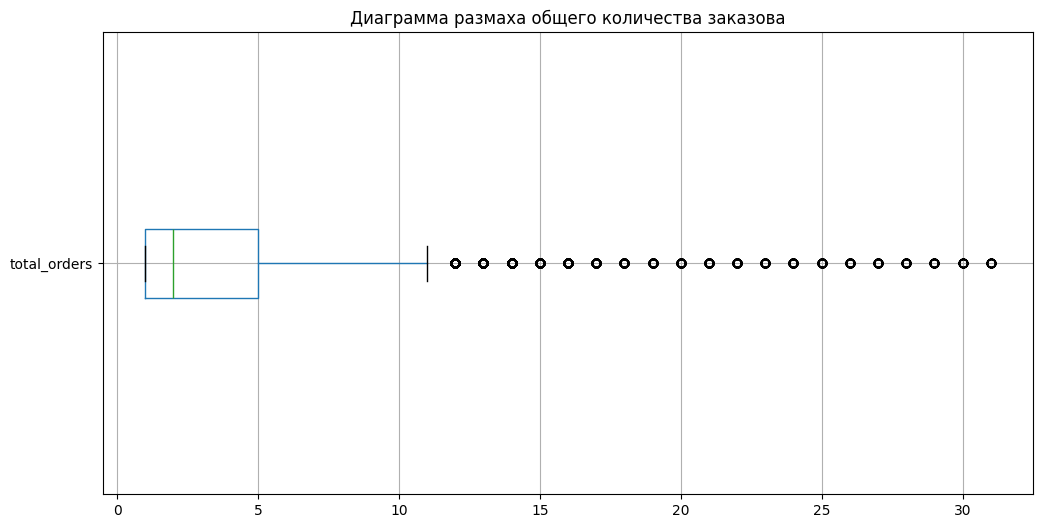

In [71]:
df_user_profile.boxplot(
    column="total_orders",
    vert=False,
    figsize=(12, 6),
)
plt.title("Диаграмма размаха общего количества заказова")
plt.show()

Для удаления выбросов в данных общего количества заказов, данные были отфильтрованы по 95 перцентилю. Было удалено 1090 записей, теперь количество записей 20741.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Сгруппируем пользователей:
- по типу их первого мероприятия;
- по типу устройства, с которого совершена первая покупка;
- по региону проведения мероприятия из первого заказа;
- по билетному оператору, продавшему билеты на первый заказ.

In [72]:
first_order_event_type_segment = df_user_profile.groupby("first_order_event_type")
first_device_type_canonical_segment = df_user_profile.groupby(
    "first_device_type_canonical"
)
first_order_region_segment = df_user_profile.groupby("first_order_region")
first_order_service_segment = df_user_profile.groupby("first_order_service")

Создаем вспомогательную функцию для подсчета количества и доли по сегментам

In [73]:
def calc_count_and_share_for_segment(group, df):
    print(
        pd.DataFrame(
            {
                "count": group["first_order_ts"].count(),
                "share": group["first_order_ts"].count() / len(df),
            }
        ).sort_values(by="count", ascending=False)
    )

In [74]:
calc_count_and_share_for_segment(first_order_event_type_segment, df_user_profile)

                        count     share
first_order_event_type                 
концерты                 9192  0.443180
другое                   5149  0.248252
театр                    4071  0.196278
стендап                  1069  0.051540
спорт                     765  0.036883
выставки                  401  0.019334
ёлки                       94  0.004532


In [75]:
calc_count_and_share_for_segment(first_device_type_canonical_segment, df_user_profile)

                             count     share
first_device_type_canonical                 
mobile                       17206  0.829565
desktop                       3535  0.170435


In [76]:
calc_count_and_share_for_segment(first_order_region_segment, df_user_profile)

                          count     share
first_order_region                       
Каменевский регион         6781  0.326937
Североярская область       3593  0.173232
Широковская область        1184  0.057085
Озернинский край            660  0.031821
Малиновоярский округ        516  0.024878
...                         ...       ...
Залесский край                2  0.000096
Верхозёрский край             1  0.000048
Светолесский край             1  0.000048
Сосноводолинская область      1  0.000048
Яснопольский округ            1  0.000048

[81 rows x 2 columns]


In [77]:
calc_count_and_share_for_segment(first_order_service_segment, df_user_profile)

                        count     share
first_order_service                    
Билеты без проблем       4951  0.238706
Мой билет                2854  0.137602
Лови билет!              2707  0.130514
Билеты в руки            2422  0.116774
Облачко                  2108  0.101634
Весь в билетах           1234  0.059496
Лучшие билеты            1130  0.054481
Прачечная                 550  0.026518
Край билетов              438  0.021118
Дом культуры              340  0.016393
Яблоко                    308  0.014850
Тебе билет!               299  0.014416
Городской дом культуры    209  0.010077
Мир касс                  199  0.009595
За билетом!               196  0.009450
Быстробилет               159  0.007666
Show_ticket               155  0.007473
Выступления.ру             92  0.004436
Восьмёрка                  82  0.003954
Быстрый кассир             55  0.002652
Crazy ticket!              42  0.002025
Росбилет                   40  0.001929
Радио ticket               36  0.001736


Наиболее популярные по типу первого мероприятия:

| Тип мероприятия          | Количество   | Доля       |
| :--                      | ---          | ---        |
| концерты                 | 9192         | 0.443180   |
| другое                   | 5149         | 0.248252   |
| театр                    | 4071         | 0.196278   |

Значительная часть пользователей отдает предпочтение концертам ~44% и театрам ~20%. А также есть большая доля пользателей ~25% которая выбирает другие типы мероприятий (возможно следует провести дополнительные исследования чтобы понять что за типы мероприятий попадаю в эту категорию).

Большинство пользователей ~83% совершают первую покупку с мобильных устройств.

Топ-3 региона проведения мероприятий из первого заказа:

| Регион                   | Количество   | Доля       |
| :--                      | ---          | ---        |
| Каменевский регион       | 6781         | 0.326937   |
| Североярская область     | 3593         | 0.173232   |
| Широковская область      | 1184         | 0.057085   |

Топ-7 билетных операторов первого заказа:

| Оператор                 | Количество   | Доля       |
| :--                      | ---          | ---        |
| Билеты без проблем       | 4951         | 0.238706   |
| Мой билет                | 2854         | 0.137602   |
| Лови билет!              | 2707         | 0.130514   |
| Билеты в руки            | 2422         | 0.116774   |
| Облачко                  | 2108         | 0.101634   |
| Весь в билетах           | 1234         | 0.059496   |
| Лучшие билеты            | 1130         | 0.054481   |


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Создадим функцию calc_is_two_share_for_segment для расчета доли по каждому сегменту и визуализации в виде столбчатого графика

In [78]:
def calc_is_two_share_for_segment(segment_group, title):
    share = segment_group["is_two"].mean().sort_values(ascending=False)[0:10]
    print(share)
    share.plot(
        kind="bar",
        figsize=(12, 6),
        title=f"Доля пользователей совершивших два и более заказа для сегмента {title}",
    )

first_order_event_type
выставки    0.630923
театр       0.618767
концерты    0.602698
стендап     0.594013
другое      0.576034
ёлки        0.553191
спорт       0.541176
Name: is_two, dtype: float64


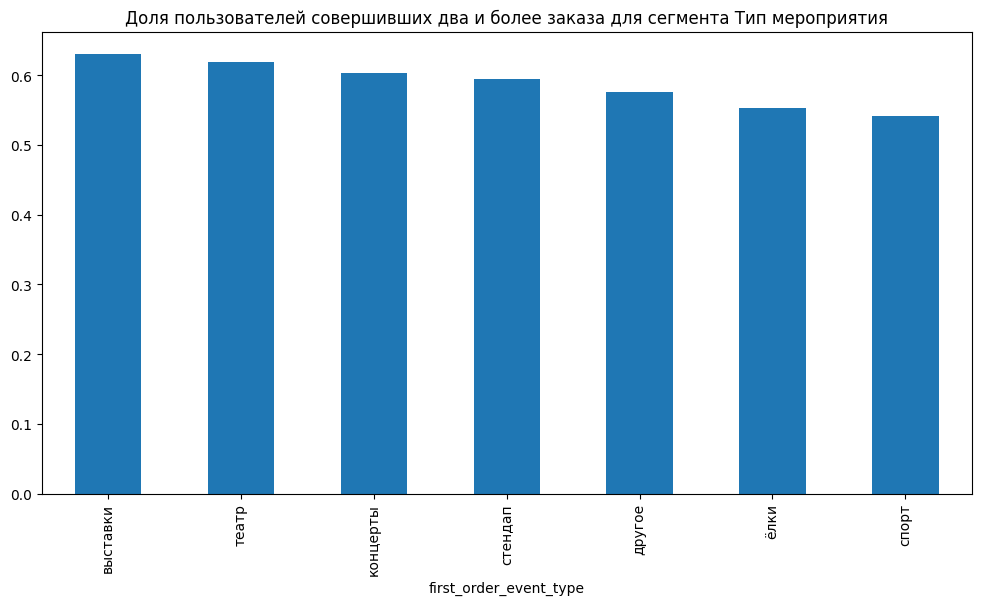

In [79]:
calc_is_two_share_for_segment(first_order_event_type_segment, "Тип мероприятия")

first_device_type_canonical
desktop    0.620368
mobile     0.592003
Name: is_two, dtype: float64


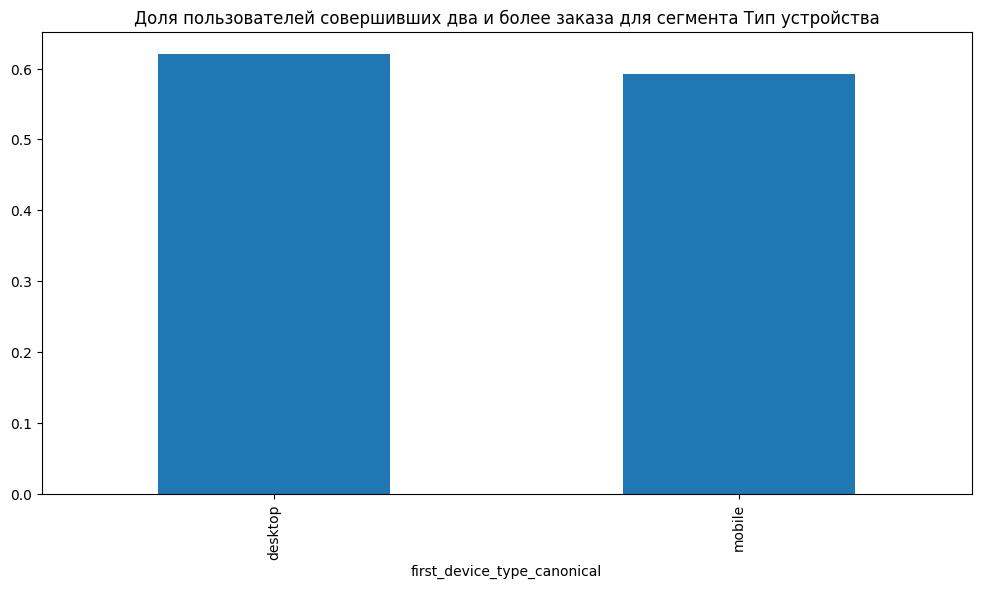

In [80]:
calc_is_two_share_for_segment(first_device_type_canonical_segment, "Тип устройства")

first_order_region
Верхозёрский край         1.000000
Озернопольская область    0.888889
Радужнопольский край      0.761905
Лесостепной край          0.690909
Лесноярский край          0.666667
Тихолесский край          0.666667
Горноземский регион       0.653846
Ягодиновская область      0.650000
Шанырский регион          0.645788
Горицветская область      0.643478
Name: is_two, dtype: float64


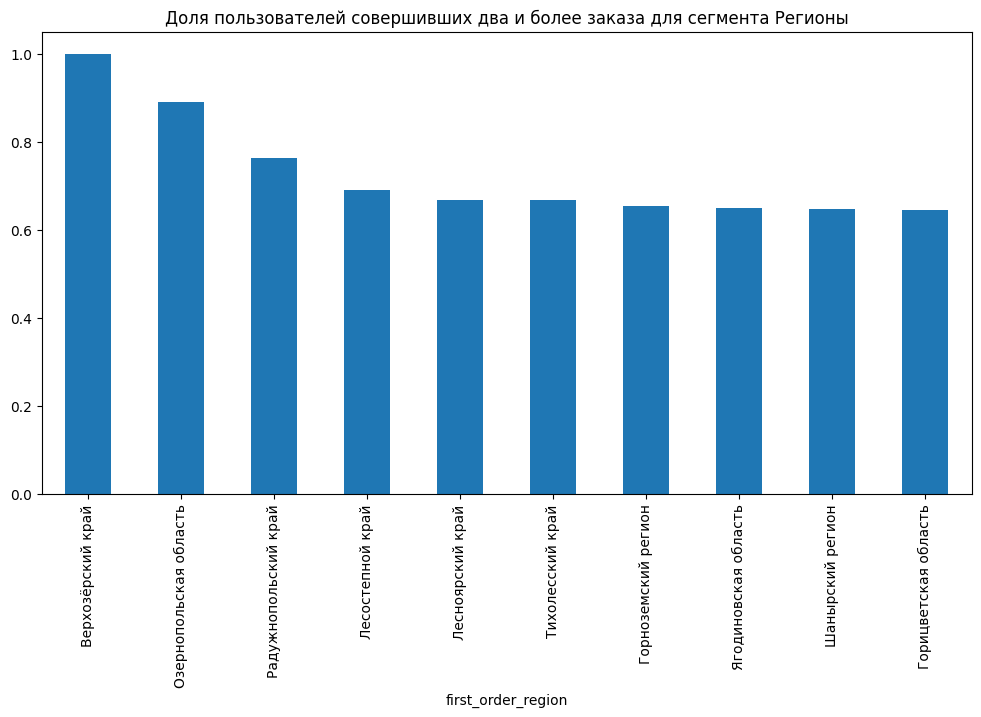

In [81]:
calc_is_two_share_for_segment(first_order_region_segment, "Регионы")

first_order_service
Зе Бест!             1.000000
Быстрый кассир       0.836364
Билет по телефону    0.833333
Реестр               0.777778
Восьмёрка            0.670732
Crazy ticket!        0.666667
Росбилет             0.650000
Show_ticket          0.645161
Край билетов         0.639269
Дом культуры         0.629412
Name: is_two, dtype: float64


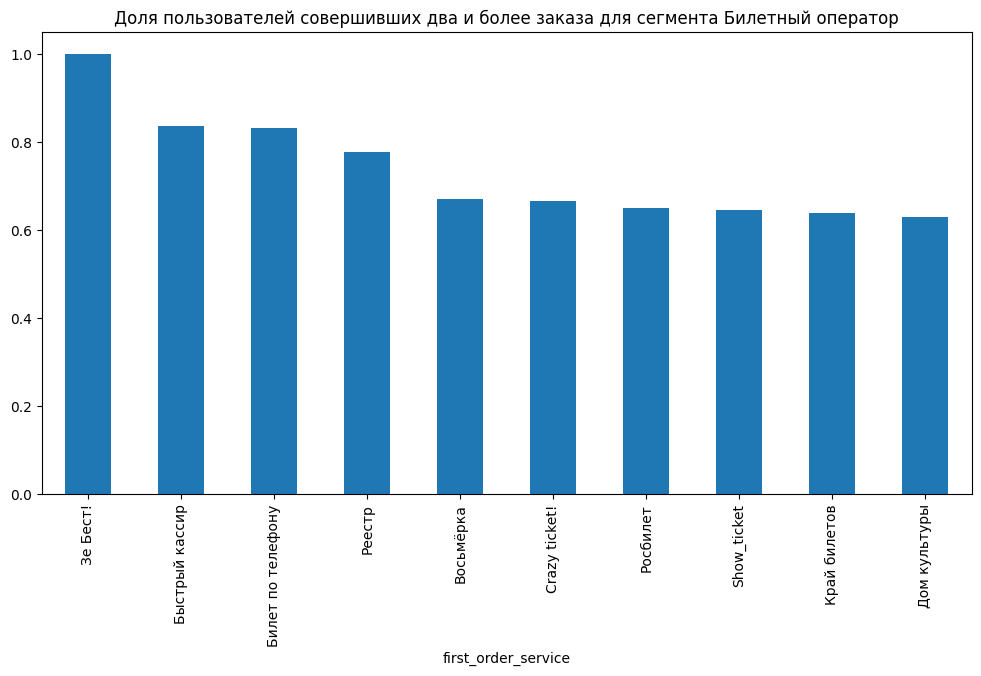

In [82]:
calc_is_two_share_for_segment(first_order_service_segment, "Билетный оператор")

Среди типов мероприятий нет явного лидера по возвратам:

| Тип мероприятия  | Доля      |
| :---             | ---       |
| выставки         | 0.630923  |
| театр            | 0.618767  |
| концерты         | 0.602698  |
| стендап          | 0.594013  |
| другое           | 0.576034  |
| ёлки             | 0.553191  |
| спорт            | 0.541176  |

При повторном заказе незначительно, но преобладает доля пользователей которые используют настольный компьютер:

| Устройство       | Доля      |
| :---             | ---       |
| desktop          | 0.620368  |
| mobile           | 0.592003  |

Успешные «точки входа» наблюдатся в трех регионах и у 4 билетных операторов:

| Регион                    |         Доля |
| :---                      | ---          |
| Верхозёрский край         | 1.000000     |
| Озернопольская область    | 0.888889     |
| Радужнопольский край      | 0.761905     |

| Оператора        |    Доля   |
| :---             | ---       |
| Зе Бест!         | 1.000000  |
| Быстрый кассир   | 0.836364  |
| Билет по телефону| 0.833333  |
| Реестр           | 0.777778  |

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1.** Гипотеза противоречит данным. Доля совершивших повторный заказ для концертов ~0.60, а для мероприятий типа спорт ~0.54, т.е. пользователи совершившие первый заказ на концерты чаще снова заказывают чем пользователи совершившие первый заказ на спортивные мероприятия.

**Гипотеза 2.** Гипотеза противоречит данным. Данные по количеству первых и повторных заказов в разрезе регионов показывают разные регионы в топе:

| Топ регионы первые заказы      | Кол-во  | Доля
| :---                           | ---     | ---
| Каменевский регион             | 6781    | 0.326842
| Североярская область           | 3599    | 0.173471
| Широковская область            | 1183    | 0.057020
| Озернинский край               |  660    | 0.031812
| Малиновоярский округ           |  516    | 0.024871

| Топ регионы повторные заказы    | Доля повторных
| :---                            | ---
| Верхозёрский край               | 1.000000
| Озернопольская область          | 0.888889
| Радужнопольский край            | 0.761905
| Лесостепной край                | 0.690909
| Тихолесский край                | 0.666667

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


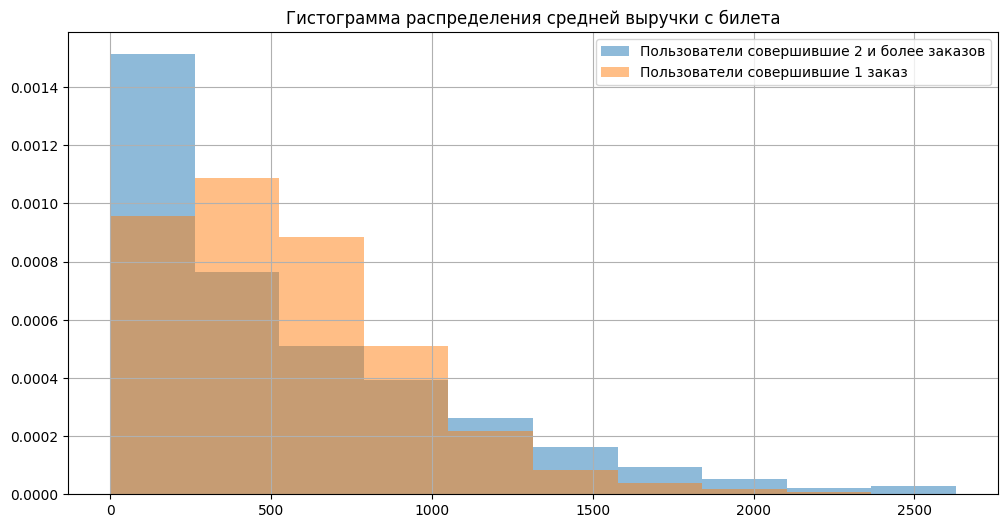

In [83]:
df_user_profile.groupby("is_two")["avg_revenue_rub"].hist(
    bins=10,
    density=True,
    alpha=0.5,
    figsize=(12, 6),
)

plt.title("Гистограмма распределения средней выручки с билета")
plt.legend(
    [
        "Пользователи совершившие 2 и более заказов",
        "Пользователи совершившие 1 заказ",
    ]
)
plt.show()

Пользователи совершившие 1 заказ чаще совершают заказ в районе 250-500 рублей. 

Пользователи совершившие 2 и более заказов чаще отдают предпочтения заказ до 250 рублей.

Пользователи совершившие 1 заказ склоны совершать более дорогие заказы, это можно наблюдать среди заказов на суммы от 250 до ~1100 рублей.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


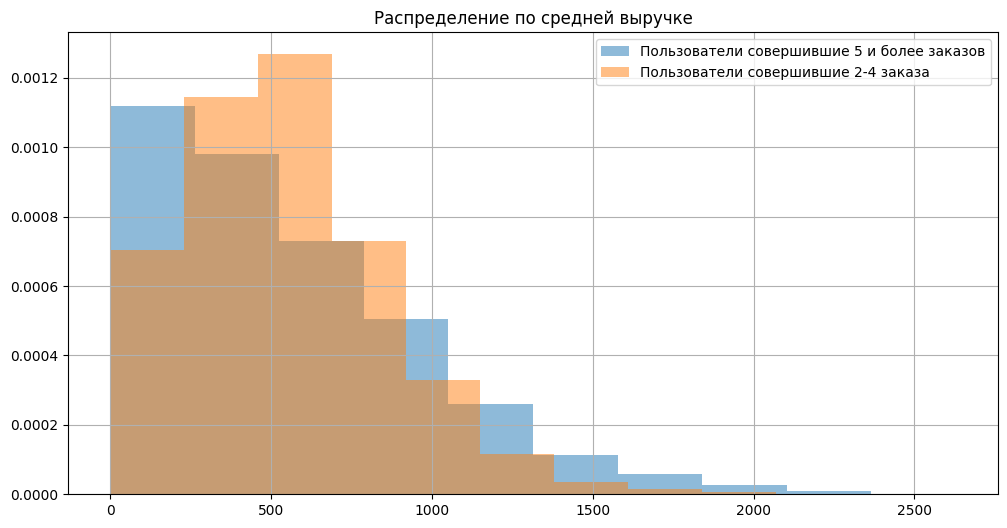

In [84]:
df_user_profile[df_user_profile["is_two"] == True].groupby("is_five")[
    "avg_revenue_rub"
].hist(
    bins=10,
    density=True,
    alpha=0.5,
    figsize=(12, 6),
)

plt.title("Распределение по средней выручке")
plt.legend(
    [
        "Пользователи совершившие 5 и более заказов",
        "Пользователи совершившие 2-4 заказа",
    ]
)
plt.show()

Пользователи совершившие 2-4 заказа чаще совершают заказы в диапазоне от 250 до ~800 рублей, тогда как пользователи совершившие 5 и более заказов чаще совершают заказы до 250 рублей.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Создадим вспомогательную функцию calc_avg_tickets_count_segment, а также создадим датасет и будет добавлять в него данные.

In [85]:
df_avg_tickets_count_segments = pd.DataFrame({"segment": [], "total": [], "share": []})


def calc_avg_tickets_count_segment(df, count_from, count_to, title):
    segment = df[
        (df["avg_tickets_count"] >= count_from) & (df["avg_tickets_count"] < count_to)
    ]
    print(f"Сегмент {title}")
    print(f"Всего: {len(segment)}")
    print(f"Доля совершивших повторные заказы {segment['is_two'].sum() / len(segment)}")
    df_avg_tickets_count_segments.loc[len(df_avg_tickets_count_segments.index)] = [
        f"Сегмент {title}",
        len(segment),
        segment["is_two"].sum() / len(segment),
    ]

In [86]:
calc_avg_tickets_count_segment(df_user_profile, 1, 2, "от 1 до 2 билетов")

Сегмент от 1 до 2 билетов
Всего: 2407
Доля совершивших повторные заказы 0.5118404653095139


In [87]:
calc_avg_tickets_count_segment(df_user_profile, 2, 3, "от 2 до 3 билетов")

Сегмент от 2 до 3 билетов
Всего: 8757
Доля совершивших повторные заказы 0.7136005481329223


In [88]:
calc_avg_tickets_count_segment(df_user_profile, 3, 5, "от 3 до 5 билетов")

Сегмент от 3 до 5 билетов
Всего: 8929
Доля совершивших повторные заказы 0.5356702878261843


In [89]:
calc_avg_tickets_count_segment(df_user_profile, 5, 100, "от 5 и более билетов")

Сегмент от 5 и более билетов
Всего: 648
Доля совершивших повторные заказы 0.17746913580246915


In [90]:
df_avg_tickets_count_segments.sort_values(by="share", ascending=False)

,segment,total,share
1,Сегмент от 2 до 3 билетов,8757,0.713601
2,Сегмент от 3 до 5 билетов,8929,0.535670
0,Сегмент от 1 до 2 билетов,2407,0.511840
3,Сегмент от 5 и более билетов,648,0.177469


<Axes: xlabel='segment'>

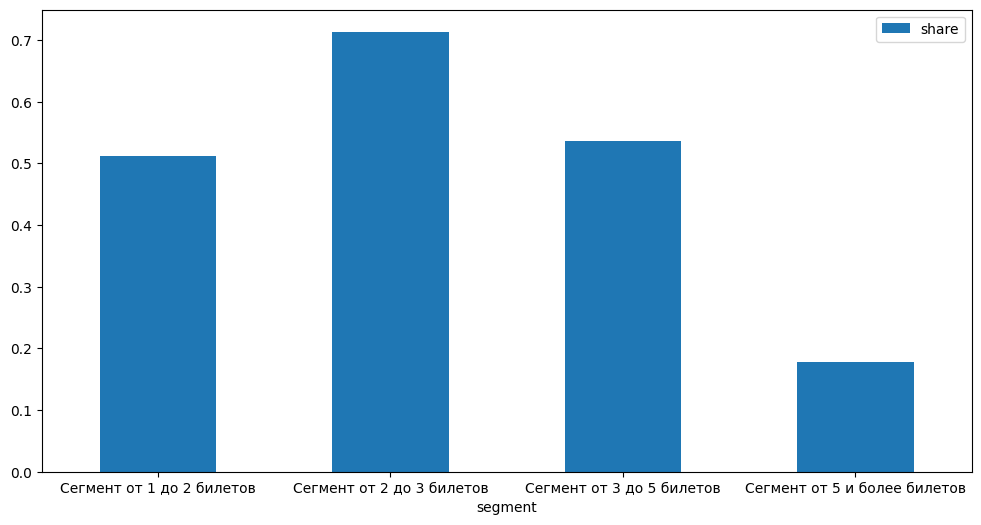

In [91]:
df_avg_tickets_count_segments.plot(
    kind="bar",
    title="",
    figsize=(12, 6),
    x="segment",
    y="share",
    rot=0,
)

Наиболее выраженны повторные заказы в сегмент от 2 до 3 билетов (доля повторных заказов \~0.71), а реже всего совершают повторные заказы в сегменте от 5 и более билетов (доля \~0.18). В сегментах от 1 до 2 билетов и от 3 до 5 билетов наблюдается примерно одинаковая доля повторных заказов (\~0.51 и \~0.54 соответствено).

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Добавим день недели в датафрейм

In [92]:
df_user_profile["first_order_weekday"] = df_user_profile["first_order_ts"].dt.weekday

Вычислим количество заказов по дням недели и долю повторных заказов

In [93]:
groupby_weekday = df_user_profile.groupby("first_order_weekday").agg(
    count=("first_order_ts", "count"),
    share_is_two=("is_two", "mean"),
)

display(groupby_weekday)

,count,share_is_two
first_order_weekday,,
0,2812,0.615932
1,3026,0.599471
2,2960,0.609459
3,3025,0.583140
4,3162,0.585705
5,3117,0.603786
6,2639,0.580144


<Axes: title={'center': 'Кол-во первых заказов по дням недели'}, xlabel='first_order_weekday'>

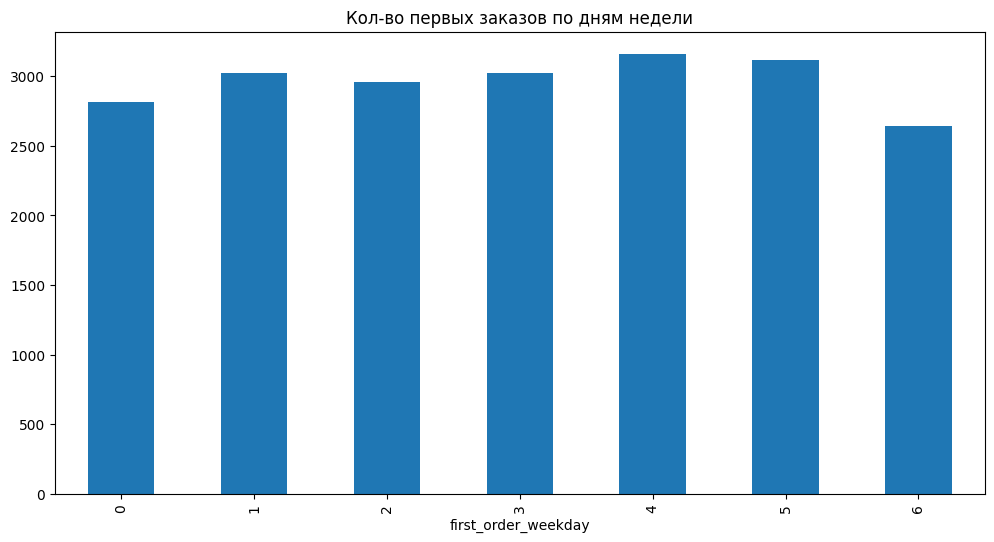

In [94]:
groupby_weekday["count"].plot.bar(
    title="Кол-во первых заказов по дням недели",
    figsize=(12, 6),
)

<Axes: title={'center': 'Доля повторных по дням недели'}, xlabel='first_order_weekday'>

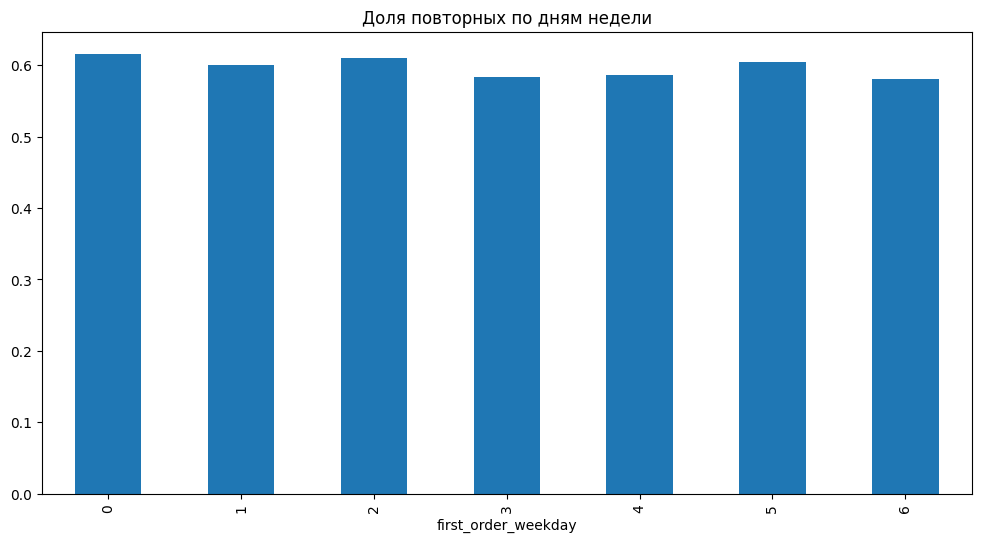

In [95]:
groupby_weekday["share_is_two"].plot.bar(
    title="Доля повторных по дням недели",
    figsize=(12, 6),
)

В данных нет ярко выраженных отличий повторных заказов в зависимости от дня недели первого заказа (доли повторных заказов находятся в диапазоне от \~0.58 до \~0.62)

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Отфильтруем заказы по которым нет повторных заказов

In [96]:
df_user_profile_with_several_orders = df_user_profile[df_user_profile["is_two"] == True]

Расчитаем средней интервал заказов для двух групп пользователей

In [97]:
df_user_profile_with_several_orders.groupby("is_five")["avg_days_since_prev"].mean()

is_five
False    21.308458
True     11.127805
Name: avg_days_since_prev, dtype: float32

Средний интервал для группы совершивших 2–4 заказа - 21 день.

Средний интервал для группы совершивших 5 и более заказов - 11 дней.

Пользователи совершающие больше заказов делают это обычно чаще (т.е у них более короткий интервал между заказами - для выше приведенных групп почти в два раза 21 против 11).

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Построим корреляционную матрицу

In [98]:
correlation_matrix = df_user_profile[
    [
        "first_device_type_canonical",
        "first_order_region",
        "first_order_service",
        "first_order_event_type",
        "total_orders",
        "avg_revenue_rub",
        "avg_tickets_count",
        "avg_days_since_prev",
    ]
].phik_matrix(
    interval_cols=[
        "total_orders",
        "avg_revenue_rub",
        "avg_tickets_count",
        "avg_days_since_prev",
    ]
)

Подготовим данные для тепловой карты

In [99]:
data_heatmap = correlation_matrix.loc[correlation_matrix.index != "total_orders"][
    ["total_orders"]
].sort_values(by="total_orders", ascending=False)
data_heatmap

,total_orders
avg_days_since_prev,0.489873
avg_tickets_count,0.414668
avg_revenue_rub,0.263681
first_device_type_canonical,0.048877
first_order_service,0.036906
first_order_event_type,0.032923
first_order_region,0.020857


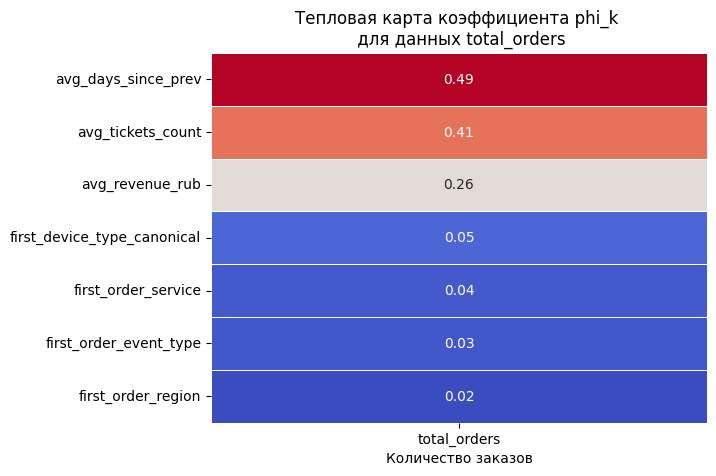

<Figure size 200x600 with 0 Axes>

In [100]:
data_heatmap = correlation_matrix.loc[correlation_matrix.index != "total_orders"][
    ["total_orders"]
].sort_values(by="total_orders", ascending=False)
sns.heatmap(
    data_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=False,
)
plt.title("Тепловая карта коэффициента phi_k \n для данных total_orders")
plt.xlabel("Количество заказов")
plt.figure(figsize=(2, 6))
plt.show()

Анализ показал, что наибольшее влияние на количество заказов оказывают следующие признаки:

- среднее количество дней между заказами (avg_days_since_prev)	\~0.49
- среднее количество билетов (avg_tickets_count) \~0.3
- средняя цена заказа (avg_revenue_rub) \~0.26

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Информация о данных, и их подготовке**

Всего в исходном датафрейме было 290611 записей и 15 колонок. Т.к в выручка по части заказов была отражена в тенге, был добавлен столбец revenue_rub с вычисленой выручкой в рублях на дату совершения заказа.

В исходных данных присутствуют пропуски в колонке days_since_prev, данные пропуски соответсвуют пользователям которые пришли первый раз и важны для исследований.

В столбце tickets_count были обнаружены выбросы и данные были отфильтрованы по 99 перцентилю. 561 записей было удалено.

В результате обработки данных столбца revenue_rub были удалены записи с отрицательными значениями (381 запись), а также отфильтрованны выбросы по 99 перцентилю (2444 записи) 

В итоговом датафрейме осталось 287786 записей.

**Профиль пользователей**

Был составлен профиль пользователя:
- Общее число пользователей в выборке 21831
- Средняя выручка с одного заказа ~544.8
- Доля пользователей, совершивших 2 и более заказа ~62%
- Доля пользователей, совершивших 5 и более заказов ~29%

Для удаления выбросов в данных общего количества заказов, данные были отфильтрованы по 95 перцентилю (удалено 1090 записей, всего осталось 20741).

**Результаты анализа**

**Исследование признаков первого заказа и их связи с возвращением на платформу**

Значительная часть пользователей при первом заказе отдает предпочтение концертам ~44% и театрам ~20%. А также есть большая доля пользателей ~25% которая выбирает другие типы мероприятий (возможно следует провести дополнительные исследования чтобы понять что за типы мероприятий попадаю в эту категорию).

Большинство пользователей ~83% совершают первую покупку с мобильных устройств.

Топ-3 региона проведения мероприятий из первого заказа:

| Регион                   | Количество   | Доля       |
| :--                      | ---          | ---        |
| Каменевский регион       | 6781         | 0.326937   |
| Североярская область     | 3593         | 0.173232   |
| Широковская область      | 1184         | 0.057085   |

Топ-7 билетных операторов первого заказа:

| Оператор                 | Количество   | Доля       |
| :--                      | ---          | ---        |
| Билеты без проблем       | 4951         | 0.238706   |
| Мой билет                | 2854         | 0.137602   |
| Лови билет!              | 2707         | 0.130514   |
| Билеты в руки            | 2422         | 0.116774   |
| Облачко                  | 2108         | 0.101634   |
| Весь в билетах           | 1234         | 0.059496   |
| Лучшие билеты            | 1130         | 0.054481   |

Среди типов мероприятий нет явного лидера по повторным заказам (доли распределенны примерно равномерно от 0.54 для спорта до 0.63 у выставок)

При повторном заказе незначительно, но преобладает доля пользователей которые используют настольный компьютер (0.62 против 0.59).

Успешные «точки входа» наблюдатся в трех регионах и у 4 билетных операторов:

| Регион                    |         Доля |
| :---                      | ---          |
| Верхозёрский край         | 1.000000     |
| Озернопольская область    | 0.888889     |
| Радужнопольский край      | 0.761905     |

| Оператора        |    Доля   |
| :---             | ---       |
| Зе Бест!         | 1.000000  |
| Быстрый кассир   | 0.836364  |
| Билет по телефону| 0.833333  |
| Реестр           | 0.777778  |

**Исследование поведения пользователей через показатели выручки и состава заказа**

Пользователи совершившие 1 заказ чаще совершают заказ в районе 250-500 рублей.

Пользователи совершившие 2 и более заказов чаще отдают предпочтения заказ до 250 рублей.

Пользователи совершившие 1 заказ склоны совершать более дорогие заказы, это можно наблюдать среди заказов на суммы от 250 до \~1100 рублей.

Пользователи совершившие 2-4 заказа чаще совершают заказы в диапазоне от 250 до ~800 рублей, тогда как пользователи совершившие 5 и более заказов чаще совершают заказы до 250 рублей.

Наиболее выраженны повторные заказы в сегмент от 2 до 3 билетов (доля повторных заказов \~0.71), а реже всего совершают повторные заказы в сегменте от 5 и более билетов (доля \~0.18). В сегментах от 1 до 2 билетов и от 3 до 5 билетов наблюдается примерно одинаковая доля повторных заказов (\~0.51 и \~0.54 соответствено).

**Исследование временных характеристик первого заказа и их влияния на повторные покупки**

В данных нет ярко выраженных отличий повторных заказов в зависимости от дня недели первого заказа (доли повторных заказов находятся в диапазоне от \~0.58 до \~0.62)

Средний интервал для группы совершивших 2–4 заказа - 21 день.

Средний интервал для группы совершивших 5 и более заказов - 11 дней.

Пользователи совершающие больше заказов делают это обычно чаще (т.е у них более короткий интервал между заказами - для выше приведенных групп почти в два раза 21 против 11).

**Корреляционный анализ количества покупок и признаков пользователя**

Анализ показал, что наибольшее влияние на количество заказов оказывают следующие признаки:

- среднее количество дней между заказами (avg_days_since_prev)	\~0.49
- среднее количество билетов (avg_tickets_count) \~0.3
- средняя цена заказа (avg_revenue_rub) \~0.26

**Рекомендации**

- Важно сокращать период между заказами (использовать акции и нотификацию)
- В рекламных компаниях стоит отдавать приоритет мобильным устройствам
- Отдавать предпочтение в рекомендация мероприятим до 500 рублей

Следует провести дополнительные исследования мероприятий которые попадают в категорию типа 'другие' (доля среди первых заказов \~25%).

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.